In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
df = pd.read_csv("../data/processed/hr_attrition_v2.csv")
df_scored = pd.read_csv("../data/processed/hr_attrition_scored_v1.csv")

df.head(), df_scored.head()

(   Age     BusinessTravel              Department  DistanceFromHome  \
 0   41      Travel_Rarely                   Sales                 1   
 1   49  Travel_Frequently  Research & Development                 8   
 2   37      Travel_Rarely  Research & Development                 2   
 3   33  Travel_Frequently  Research & Development                 3   
 4   27      Travel_Rarely  Research & Development                 2   
 
    Education EducationField  EnvironmentSatisfaction  Gender  JobInvolvement  \
 0          2  Life Sciences                        2  Female               3   
 1          1  Life Sciences                        3    Male               2   
 2          2          Other                        4    Male               2   
 3          4  Life Sciences                        4  Female               3   
 4          1        Medical                        1    Male               3   
 
    JobLevel  ... YearsWithCurrManager  income_log tenure_ratio  \
 0         

In [3]:
target_col = "attrition_flag"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("숫자형 변수 수:", len(numeric_cols))
print("범주형 변수 수:", len(categorical_cols))
print(categorical_cols)

숫자형 변수 수: 25
범주형 변수 수: 10
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'age_group', 'income_group', 'tenure_group']


In [4]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

final_logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]
)

final_logit_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [5]:
feature_names = final_logit_model.named_steps["preprocessor"].get_feature_names_out()
coef = final_logit_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

coef_df.head(30)

,feature,coef,abs_coef
52,cat__OverTime_Yes,0.955369,0.955369
25,cat__BusinessTravel_Non-Travel,-0.954145,0.954145
26,cat__BusinessTravel_Travel_Frequently,0.921956,0.921956
50,cat__MaritalStatus_Single,0.808411,0.808411
51,cat__OverTime_No,-0.796015,0.796015
60,cat__income_group_중상,-0.690700,0.690700
36,cat__EducationField_Technical Degree,0.680235,0.680235
55,cat__age_group_36-45,-0.657516,0.657516
59,cat__income_group_저소득,0.637674,0.637674
20,num__income_log,0.627752,0.627752


In [6]:
positive_coef_df = coef_df.sort_values("coef", ascending=False).head(15)
negative_coef_df = coef_df.sort_values("coef", ascending=True).head(15)

print("이직 가능성을 높이는 방향의 변수")
display(positive_coef_df)

print("이직 가능성을 낮추는 방향의 변수")
display(negative_coef_df)

이직 가능성을 높이는 방향의 변수


,feature,coef,abs_coef
52,cat__OverTime_Yes,0.955369,0.955369
26,cat__BusinessTravel_Travel_Frequently,0.921956,0.921956
50,cat__MaritalStatus_Single,0.808411,0.808411
36,cat__EducationField_Technical Degree,0.680235,0.680235
59,cat__income_group_저소득,0.637674,0.637674
20,num__income_log,0.627752,0.627752
41,cat__JobRole_Laboratory Technician,0.566443,0.566443
62,cat__tenure_group_0-2년,0.456873,0.456873
47,cat__JobRole_Sales Representative,0.390391,0.390391
30,cat__Department_Sales,0.370938,0.370938


이직 가능성을 낮추는 방향의 변수


,feature,coef,abs_coef
25,cat__BusinessTravel_Non-Travel,-0.954145,0.954145
51,cat__OverTime_No,-0.796015,0.796015
60,cat__income_group_중상,-0.690700,0.690700
55,cat__age_group_36-45,-0.657516,0.657516
48,cat__MaritalStatus_Divorced,-0.622553,0.622553
4,num__JobInvolvement,-0.444369,0.444369
32,cat__EducationField_Life Sciences,-0.433629,0.433629
3,num__EnvironmentSatisfaction,-0.410992,0.410992
6,num__JobSatisfaction,-0.403794,0.403794
23,num__manager_tenure_ratio,-0.399457,0.399457


In [7]:
coef_df["feature_clean"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

positive_clean = coef_df.sort_values("coef", ascending=False).head(15).copy()
negative_clean = coef_df.sort_values("coef", ascending=True).head(15).copy()

positive_clean[["feature_clean", "coef"]]
negative_clean[["feature_clean", "coef"]]

,feature_clean,coef
25,BusinessTravel_Non-Travel,-0.954145
51,OverTime_No,-0.796015
60,income_group_중상,-0.690700
55,age_group_36-45,-0.657516
48,MaritalStatus_Divorced,-0.622553
4,JobInvolvement,-0.444369
32,EducationField_Life Sciences,-0.433629
3,EnvironmentSatisfaction,-0.410992
6,JobSatisfaction,-0.403794
23,manager_tenure_ratio,-0.399457


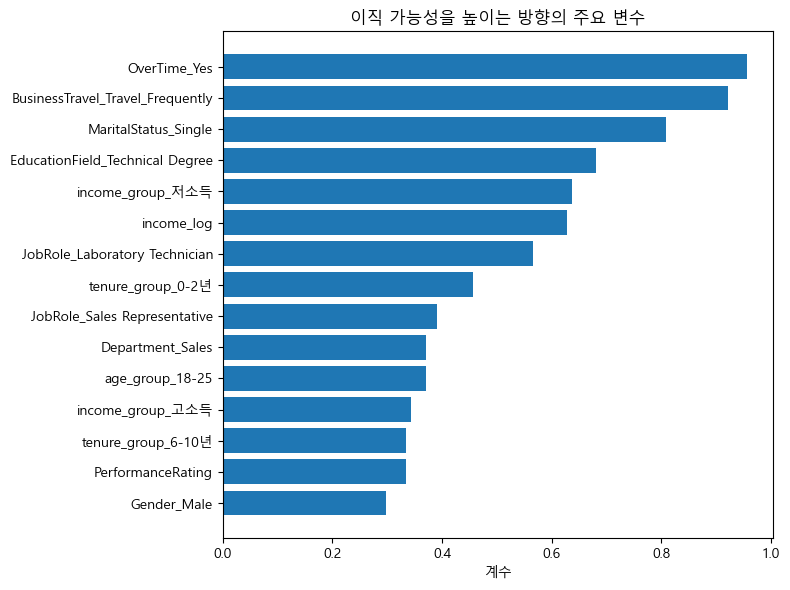

In [8]:
plot_pos = positive_clean.sort_values("coef", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(plot_pos["feature_clean"], plot_pos["coef"])
plt.title("이직 가능성을 높이는 방향의 주요 변수")
plt.xlabel("계수")
plt.tight_layout()
plt.show()

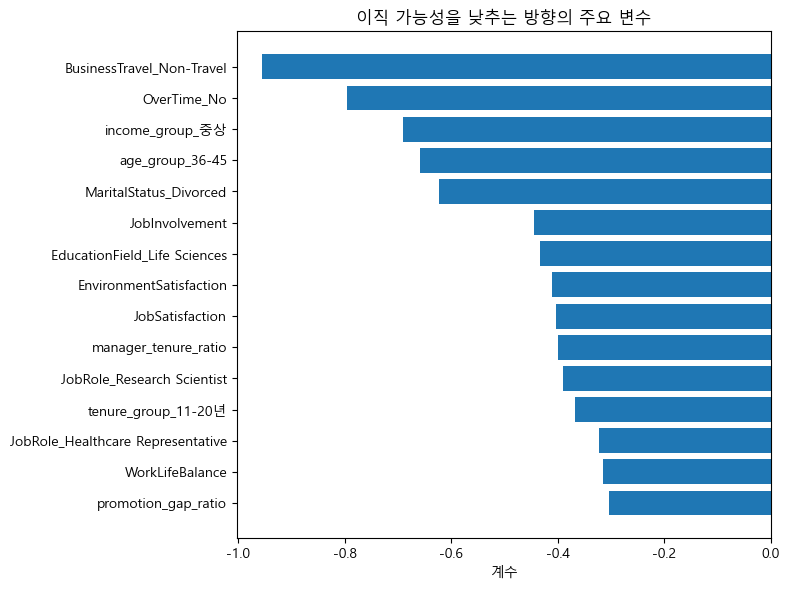

In [9]:
plot_neg = negative_clean.sort_values("coef", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(plot_neg["feature_clean"], plot_neg["coef"])
plt.title("이직 가능성을 낮추는 방향의 주요 변수")
plt.xlabel("계수")
plt.tight_layout()
plt.show()

In [10]:
segment_summary = (
    df_scored.groupby("risk_segment")["attrition_flag"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

priority_summary = (
    df_scored.groupby("intervention_priority")["attrition_flag"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

segment_summary, priority_summary

(                  mean  count
 risk_segment                 
 High Risk     0.666667    147
 Medium Risk   0.268707    294
 Low Risk      0.058309   1029,
                            mean  count
 intervention_priority                 
 선별 검토 대상               0.698413    126
 즉시 유지 개입               0.476190     21
 모니터링 대상                0.285141    249
 예방적 케어 대상              0.177778     45
 핵심인재 일반 케어             0.064057    281
 일반 모니터링                0.056150    748)

In [11]:
insight_cols = [
    "OverTime", "BusinessTravel", "MaritalStatus",
    "JobRole", "Department", "age_group", "income_group", "tenure_group"
]

for col in insight_cols:
    result = (
        df_scored.groupby(col)["attrition_flag"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )
    print(f"\n===== {col} =====")
    print(result.head(10))


===== OverTime =====
              mean  count
OverTime                 
Yes       0.305288    416
No        0.104364   1054

===== BusinessTravel =====
                       mean  count
BusinessTravel                    
Travel_Frequently  0.249097    277
Travel_Rarely      0.149569   1043
Non-Travel         0.080000    150

===== MaritalStatus =====
                   mean  count
MaritalStatus                 
Single         0.255319    470
Married        0.124814    673
Divorced       0.100917    327

===== JobRole =====
                               mean  count
JobRole                                   
Sales Representative       0.397590     83
Laboratory Technician      0.239382    259
Human Resources            0.230769     52
Sales Executive            0.174847    326
Research Scientist         0.160959    292
Manufacturing Director     0.068966    145
Healthcare Representative  0.068702    131
Manager                    0.049020    102
Research Director          0.025000   

In [12]:
coef_df.to_csv("../outputs/tables/logistic_coefficients_full.csv", index=False, encoding="utf-8-sig")
positive_clean.to_csv("../outputs/tables/logistic_positive_coefficients_top15.csv", index=False, encoding="utf-8-sig")
negative_clean.to_csv("../outputs/tables/logistic_negative_coefficients_top15.csv", index=False, encoding="utf-8-sig")

print("저장 완료")

저장 완료


설명가능성 및 결과 요약 메모

- 최종 기준 모델은 해석 가능성과 안정성이 높은 로지스틱 회귀로 선정
- 본 단계의 목적 : 이직 리스크에 영향을 주는 주요 변수의 방향성과 상대적 중요도 정리
- 계수 기반 explainability를 통해 근무부담, 보상 수준, 조직 정착도, 직무 특성의 영향 구조 확인
- 리스크 세그먼트 결과와 결합하여 예측 결과를 HR 개입 우선순위와 연결 가능한 형태로 정리
- 최종 포트폴리오 메시지는 예측 정확도 자체보다 설명 가능성과 실행 가능성 중심으로 구성